In [102]:
import pandas as pd

In [103]:
# df = pd.read_csv('results/pu_classify_results_Cora.csv')
# df = pd.read_csv('results/final_pu_classify_results_CiteSeer.csv')
# df = pd.read_csv('results/final_pu_classify_results_PubMed.csv')
# df = pd.read_csv('results/pu_classify_results_Photo.csv')
# df = pd.read_csv('results/pu_classify_results_dblp.csv')

df = pd.read_csv('results/neg_inf_results_PubMed.csv')



FileNotFoundError: [Errno 2] No such file or directory: 'results/neg_inf_results_PubMed.csv'

In [ ]:
df.columns

Index(['Unnamed: 0', 'acc', 'f1', 'precision', 'recall', '1/1', '0/0', '0/1',
       '1/0', 'model', 'dataset', 'rate', 'length negatives',
       'length positives'],
      dtype='object')

In [ ]:
import pandas as pd

# Supondo que seu dataframe seja df
# df_grouped = df.groupby(['rate', 'model'])[['acc', 'f1']].mean().reset_index()

df_grouped = df.groupby(['rate', 'model'])['f1'].agg(
    f1='mean',
    f1_std='std'
).reset_index()


In [ ]:
model_name = 'RGraphSage'

In [ ]:
df_grouped[df_grouped['model'] ==model_name]

,rate,model,f1,f1_std


In [ ]:
def format_f1_with_std(df):
    return df.apply(lambda row: f"{round(row['f1'], 4)} ± {round(row['f1_std'], 2)}", axis=1)

In [ ]:
latex_df = df_grouped[df_grouped['model'] == model_name][['f1', 'f1_std']]


latex_df['f1_fmt'] = format_f1_with_std(latex_df)

output_str = ''

for value in latex_df['f1_fmt']:
    output_str += value + ' & ' 

output_str = output_str[:-2]
output_str = model_name + '&  ' + output_str + r'\\hline'


output_str

'RGraphSage&  \\\\hline'

In [ ]:
df_grouped[df_grouped['rate'] == 0.01]

,rate,model,f1,f1_std
0,0.01,DropEdgeGCN,0.97462,0.007436
1,0.01,GCN,0.98010,0.000000
2,0.01,RGCN,0.96498,0.007641
3,0.01,SkipNodeGCN,0.85462,0.041907


In [ ]:
df_grouped[df_grouped['rate'] == 0.05]

,rate,model,f1,f1_std
16,0.05,DropEdgeGCN,0.97856,0.005354
17,0.05,GCN,0.98176,0.004083
18,0.05,RGCN,0.98952,0.002087
19,0.05,SkipNodeGCN,0.91522,0.026071


In [ ]:
df_grouped[df_grouped['rate'] == 0.1]

,rate,model,f1,f1_std
36,0.1,DropEdgeGCN,0.97304,0.004468
37,0.1,GCN,0.97226,0.010467
38,0.1,RGCN,0.99400,0.001065
39,0.1,SkipNodeGCN,0.89226,0.020568


In [ ]:
df_grouped[df_grouped['rate'] == 0.15]

,rate,model,f1,f1_std
56,0.15,DropEdgeGCN,0.97318,0.010202
57,0.15,GCN,0.96360,0.007148
58,0.15,RGCN,0.99574,0.000918
59,0.15,SkipNodeGCN,0.88356,0.031870


In [ ]:
df_grouped[df_grouped['rate'] == 0.2]

,rate,model,f1,f1_std
76,0.2,DropEdgeGCN,0.96470,0.006892
77,0.2,GCN,0.96522,0.002952
78,0.2,RGCN,0.99690,0.000539
79,0.2,SkipNodeGCN,0.90164,0.011988


In [ ]:
df_grouped[df_grouped['rate'] == 0.25]

,rate,model,f1,f1_std
96,0.25,DropEdgeGCN,0.96390,0.008794
97,0.25,GCN,0.96574,0.005974
98,0.25,RGCN,0.99726,0.000541
99,0.25,SkipNodeGCN,0.90762,0.017352


# Analysis neg_inf

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# df = pd.read_csv('results/neg_inf_results_Photo.csv')
# df = pd.read_csv('results/neg_inf_results_PubMed.csv')
# df = pd.read_csv('results/neg_inf_results_dblp.csv')
# df = pd.read_csv('results/neg_inf_results_CiteSeer.csv')
# df = pd.read_csv('results/neg_inf_results_Cora.csv')
dataset_name = 'dblp'
df = pd.read_csv(f'results/final_gnn_neg_inf_results_{dataset_name}.csv')

[]

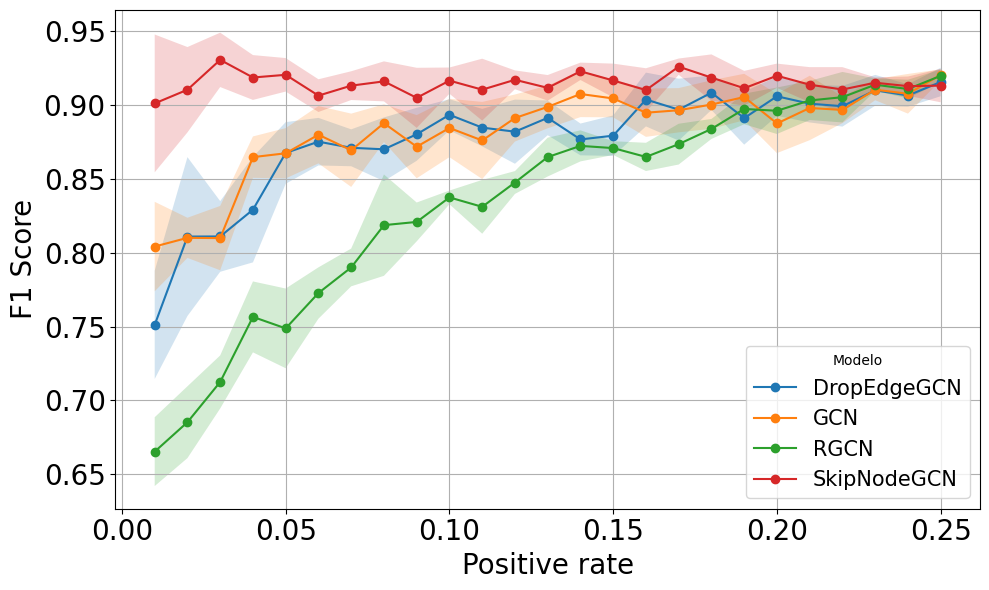

In [ ]:
import pandas as pd

# Agrupar por 'rate' e 'model', e calcular média e desvio padrão
summary = df.groupby(['rate', 'model'])['f1'].agg(['mean', 'std']).reset_index()

# Lista de modelos únicos
modelos = summary['model'].unique()

# Plot
plt.figure(figsize=(10, 6))

for model in modelos:
    dados_modelo = summary[summary['model'] == model]
    rates = dados_modelo['rate']
    medias = dados_modelo['mean']
    desvios = dados_modelo['std']
    
    # Linha principal (média do F1)
    plt.plot(rates, medias, label=model, marker = 'o')
    
    # Faixa do desvio padrão (transparente)
    plt.fill_between(rates, medias - desvios, medias + desvios, alpha=0.2)

plt.xlabel('Positive rate', fontsize = 20)
plt.ylabel('F1 Score', fontsize = 20)
# plt.title('Desempenho dos modelos com diferentes taxas de dados rotulados')
plt.legend(title='Modelo', fontsize = 15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.savefig(f'plots/neg_inf_{dataset_name}.svg', format='svg')
plt.plot()